# The volatility of the volatility — does VVIX beat the VIX? 🌀
### "Vol of vol" is supposed to be a sharper fear gauge than the VIX. Is it? — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_than_the_VIX%3F: Busted](https://img.shields.io/badge/Better_than_the_VIX%3F-Busted-8b949e?style=flat-square)

Everyone knows the **VIX**: the market's "fear gauge," the expected wobble of the S&P 500. Fewer people know its shadow, the **VVIX** — the expected wobble *of the VIX itself*. The **volatility of the volatility.** The pitch from vol traders is seductive: when the vol-of-vol spikes, the options market is pricing a shock the plain VIX hasn't caught up to yet — so VVIX should be an **earlier, sharper** risk alarm than the VIX.

It's a great story. This notebook checks whether the vol-of-vol actually *adds* anything over the VIX you can already watch for free — and finds that, once you put both gauges side by side, the extra alarm is mostly an echo.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo test and the regression that decides it? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** VVIX (`^VVIX`), VIX (`^VIX`) and SPY come straight from yfinance; VVIX's history starts in 2007, so we cover every big vol shock since the GFC. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_of_vol import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
STATE = st.vvix_state(F) if HAVE_REAL else None
print("real vol-tape cache present:", HAVE_REAL,
      "| high-VVIX days:", (0 if STATE is None else int(STATE.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-18', 'days': 4887, 'years': 19.5, 'n_high': 1059, 'frac_high': 21.7, 'h1': (1, 1059, 1.44, 69, 0.99, 67, 2.35, 0.929, -5.37, -4.13), 'h3': (3, 1046, 3.89, 73, 2.92, 73, 3.51, 0.969, -8.75, -7.66), 'inc1': {'corr': 0.41, 'vix_only_t': 1.14, 'vvix_only_t': 2.28, 'vix_t': 0.57, 'vvix_t': 1.57, 'vvix_only_b': 0.59, 'vvix_b': 0.49}, 'inc3': {'corr': 0.41, 'vix_only_t': 0.82, 'vvix_only_t': 1.74, 'vix_t': 0.39, 'vvix_t': 1.12, 'vvix_only_b': 1.27, 'vvix_b': 1.06}, 'robust': [(0.7, 1567, 1.08, 0.56), (0.8, 1059, 1.44, 2.35), (0.9, 556, 1.6, 2.25)], 'trade': {'net_ann': 8.9, 'net_vol': 13.7, 'net_sh': 0.65, 'bh_ann': 12.4, 'bh_vol': 19.6, 'bh_sh': 0.63, 'trades': 414, 'pct_flat': 22}, 'syn': [(0.0, -0.83, -1.52, -0.5), (0.04, -14.16, -15.84, -13.01), (0.1, -17.76, -19.85, -22.82)]}


real vol-tape cache present: True | high-VVIX days: 1059


## The answer first

| Question | Answer |
|---|---|
| Does a vol-of-vol spike precede a market drop? | **Not really — the opposite.** After high-VVIX days the market is, on average, *higher* a month later, because VVIX peaks at **crash bottoms** (2008, 2020) that then bounce. |
| So VVIX is useless? | **No — it flags turbulence.** High-VVIX days are followed by **deeper drawdowns** (a −5.4% vs −4.1% worst-dip). It marks a *bumpy* month, not a *down* one. |
| But is it **better than the VIX**? | **That's the whole question — and the answer is no.** Put VIX and VVIX in the same model and the vol-of-vol's edge **vanishes**: it's ~40% correlated with the VIX, so most of its "signal" is just the VIX showing through. |
| Could you trade it? | **No.** A "go to cash when vol-of-vol is high" timer ties buy-and-hold on risk-adjusted terms while giving up return. |

> Vol-of-vol is real and even mildly useful as a *turbulence* flag. But as a **sharper VIX**, it's a redundant cousin — not a new clock.

## 1 · The claim

> *"The VIX tells you how much the market is expected to move. The **VVIX** tells you how much the **VIX** is expected to move. When vol-of-vol blows out, the options market is bracing for a tail the VIX hasn't priced yet — so VVIX leads the VIX, and times equity risk **better** than it."*

VVIX is a real CBOE index: the same model-free recipe as the VIX, applied to **VIX options**. The picture is intuitive — a violent re-pricing of *uncertainty about uncertainty* feels like it should be early warning. We'll build the gauge, look at what follows a spike, and — the part that matters — ask whether it beats the plain VIX.

## 2 · So what?

If vol-of-vol really timed risk **better than the VIX**, it would be worth real money: a cheap, public series that front-runs the most-watched fear gauge on the planet. But notice the trap hiding in "better than the VIX." VVIX and VIX move together — when one is high the other usually is too. So a signal that looks predictive *might* just be the VIX wearing a costume. The only honest question isn't "does high VVIX precede trouble?" (the VIX does that too) — it's **"does VVIX add anything *once you already know the VIX*?"** Everything below builds to that one test.

## 3 · How would we even know?

We pull **4,887** days of VVIX, VIX and SPY (2007-01-03 → 2026-06-18, 20 years). Then:

1. **Mark the spikes.** A "high vol-of-vol" day = VVIX above its own trailing one-year 80th percentile (a fair, point-in-time bar). That fires about **22%** of days.
2. **Measure what follows.** After each high-VVIX day, what did SPY do over the next **1 and 3 months** — return *and* worst drawdown — vs a normal day (the base rate)?
3. **The decider.** Race VVIX against the VIX head-to-head: put **both** in one model and see whether vol-of-vol still says anything once the VIX is accounted for. If it doesn't, "better than the VIX" is busted.

## 4 · The teardown — let's actually look

**First, meet the two gauges.** VVIX (the vol-of-vol) and VIX (plain vol) over the whole sample. See how their spikes line up — that shared shape is the whole problem.

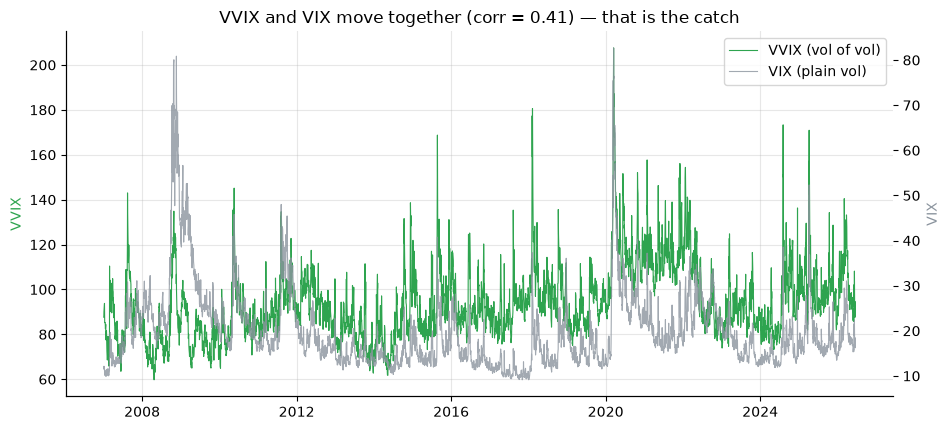

corr(VVIX, VIX) = 0.41


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(9.6, 4.4))
    ax.plot(F.index, F['vvix'], c=GREEN, lw=.8, label='VVIX (vol of vol)')
    ax2 = ax.twinx()
    ax2.plot(F.index, F['vix'], c=GREY, lw=.8, alpha=.8, label='VIX (plain vol)')
    ax.set_ylabel('VVIX', color=GREEN); ax2.set_ylabel('VIX', color=GREY)
    ax2.grid(False)
    corr = F['vvix'].corr(F['vix'])
    ax.set_title(f'VVIX and VIX move together (corr = {corr:.2f}) — that is the catch')
    l1,la1 = ax.get_legend_handles_labels(); l2,la2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, la1+la2, loc='upper right')
    plt.tight_layout(); plt.show()
    print(f'corr(VVIX, VIX) = {corr:.2f}')
else:
    print('no cache — VVIX and VIX are ~0.41 correlated; see docs/results.md')

**Now, what follows a vol-of-vol spike?** The believers expect *down*. Here's the forward 1-month win-rate after a high-VVIX day next to a normal day — and the surprise is the direction.

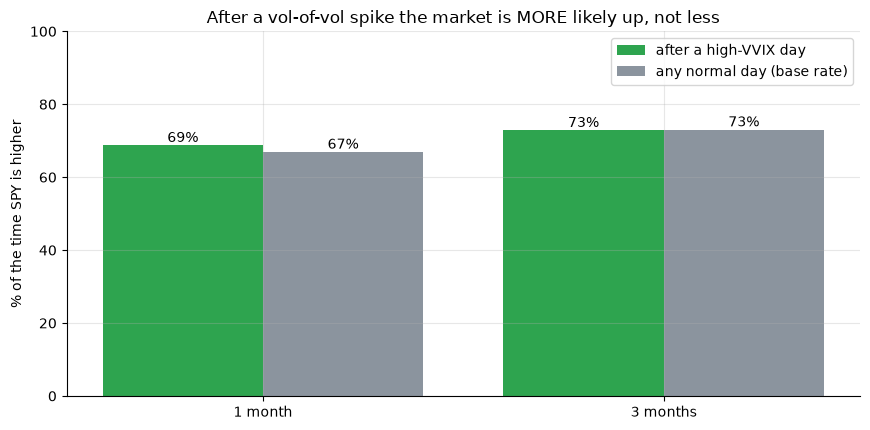

1m win-rate after high VVIX: 69%  vs base 67%


In [3]:
hs = [1, 3]
if HAVE_REAL:
    rows = [st.summarize(F, STATE, m) for m in hs]
    cwin = [r['cond_win']*100 for r in rows]; bwin = [r['base_win']*100 for r in rows]
else:
    cwin = [R['h1'][3], R['h3'][3]]; bwin = [R['h1'][5], R['h3'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-.2, cwin, .4, color=GREEN, label='after a high-VVIX day')
ax.bar(x+.2, bwin, .4, color=GREY, label='any normal day (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} month' + ('s' if m>1 else '') for m in hs])
ax.set_ylim(0, 100); ax.set_ylabel('% of the time SPY is higher')
ax.set_title('After a vol-of-vol spike the market is MORE likely up, not less')
for i,(c,b) in enumerate(zip(cwin,bwin)):
    ax.annotate(f'{c:.0f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('1m win-rate after high VVIX:', f'{cwin[0]:.0f}%', ' vs base', f'{bwin[0]:.0f}%')

There's the first twist. After a vol-of-vol spike SPY is higher a month later **69%** of the time — *above* the **67%** base rate, not below. VVIX peaks when markets are already **bottoming** (late 2008, March 2020), and bottoms bounce. So as a "sell" signal it points the **wrong way**. Where it *does* bite is **drawdowns** — let's see that.

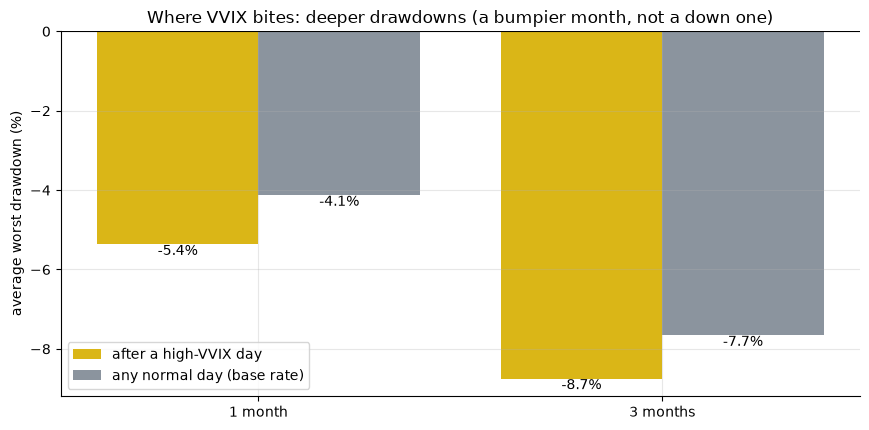

1m worst drawdown: high-VVIX -5.4%  vs base -4.1%


In [4]:
if HAVE_REAL:
    cdd = [st.summarize(F, STATE, m)['cond_dd']*100 for m in hs]
    bdd = [st.summarize(F, STATE, m)['base_dd']*100 for m in hs]
else:
    cdd = [R['h1'][8], R['h3'][8]]; bdd = [R['h1'][9], R['h3'][9]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-.2, cdd, .4, color=AMBER, label='after a high-VVIX day')
ax.bar(x+.2, bdd, .4, color=GREY, label='any normal day (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} month'+('s' if m>1 else '') for m in hs])
ax.set_ylabel('average worst drawdown (%)'); ax.axhline(0, c='k', lw=.8)
ax.set_title('Where VVIX bites: deeper drawdowns (a bumpier month, not a down one)')
for i,(c,b) in enumerate(zip(cdd,bdd)):
    ax.annotate(f'{c:.1f}%',(i-.2,c),ha='center',va='top')
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='top')
ax.legend(); plt.tight_layout(); plt.show()
print('1m worst drawdown: high-VVIX', f'{cdd[0]:.1f}%', ' vs base', f'{bdd[0]:.1f}%')

So vol-of-vol *is* a turbulence flag: after a spike the worst dip over the next month is **-5.4%** vs **-4.1%** normally. A bumpier ride — even if the month tends to *end* higher. But none of this is the real question. The real question is whether any of it beats the **VIX**.

**The decider: VVIX vs VIX, head to head.** We let each gauge predict next month's return on its own, then put **both** in one race. Watch what happens to VVIX's strength (its *t*-stat — bigger = stronger) when the VIX joins the model.

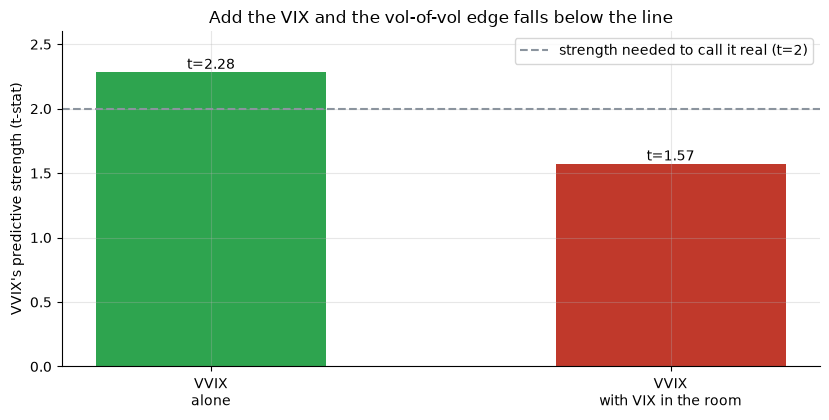

VVIX alone: t=2.28 (clears 2)  ->  with VIX: t=1.57 (fails)


In [5]:
if HAVE_REAL:
    r = st.incremental_regression(F, 1)
    vvix_alone = r['vvix_only_t']; vvix_with_vix = r['vvix_t']
else:
    vvix_alone = R['inc1']['vvix_only_t']; vvix_with_vix = R['inc1']['vvix_t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
bars = ax.bar(['VVIX\nalone', 'VVIX\nwith VIX in the room'],
              [vvix_alone, vvix_with_vix], color=[GREEN, RED], width=.5)
ax.axhline(2, ls='--', c=GREY, label='strength needed to call it real (t=2)')
for b,v in zip(bars,[vvix_alone, vvix_with_vix]):
    ax.annotate(f't={v:.2f}',(b.get_x()+b.get_width()/2, v),ha='center',va='bottom')
ax.set_ylabel("VVIX's predictive strength (t-stat)"); ax.set_ylim(0, 2.6)
ax.set_title('Add the VIX and the vol-of-vol edge falls below the line'); ax.legend()
plt.tight_layout(); plt.show()
print(f'VVIX alone: t={vvix_alone:.2f} (clears 2)  ->  with VIX: t={vvix_with_vix:.2f} (fails)')

That's the whole study in one chart. **Alone**, VVIX looks predictive (*t* = 2.28, above the line). **With the VIX in the room**, it collapses to *t* = 1.57 — below the bar. The vol-of-vol's apparent edge was mostly the VIX showing through a 0.41-correlated window. "Better than the VIX" — busted.

## 5 · The verdict

- **Signal — Weak.** High-VVIX days do precede a real *turbulence* signal (deeper drawdowns) and even a positive return bump (*t* = 2.35) — but pointed the *wrong way* for a sell signal, fragile to the threshold, and **not better than the VIX**.
- **Tradability — Mirage.** A "cash when vol-of-vol is high" timer ties buy-and-hold on risk-adjusted terms and gives up return. No edge to deploy.
- **Better than the VIX? — Busted.** Once the VIX is in the model, VVIX adds nothing robust (*t* 2.28 → 1.57). It's a redundant cousin of vol, not a sharper clock.

## 6 · Could you actually trade it?

Suppose you ignored all of that and built the obvious rule: **hold SPY, but go to cash whenever vol-of-vol is high.** Does dodging the bumpy months pay? Here's that timer against plain buy-and-hold.

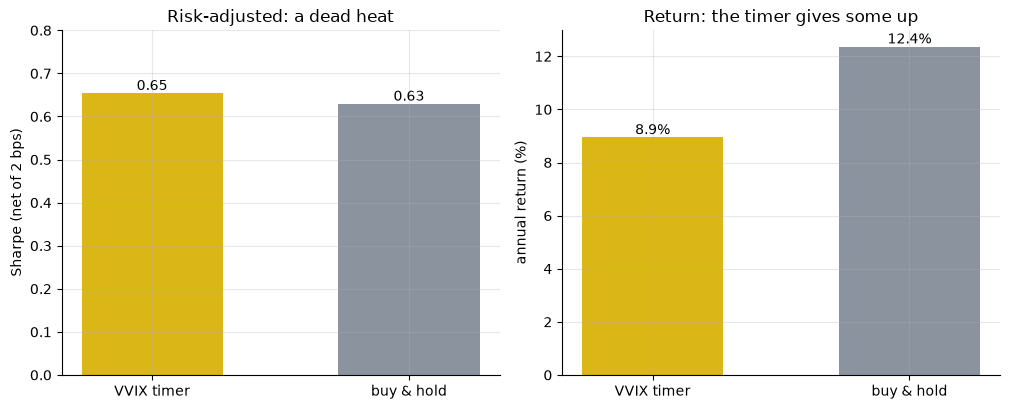

timer Sharpe 0.65 vs buy-and-hold 0.63 — a wash; timer earns less


In [6]:
if HAVE_REAL:
    bt = st.timing_backtest(F, STATE)
    net_sh, bh_sh = bt['net_sharpe'], bt['bh_sharpe']
    net_ann, bh_ann = bt['net_ann']*100, bt['bh_ann']*100
    net_vol, bh_vol = bt['net_vol']*100, bt['bh_vol']*100
else:
    t = R['trade']; net_sh, bh_sh = t['net_sh'], t['bh_sh']
    net_ann, bh_ann = t['net_ann'], t['bh_ann']; net_vol, bh_vol = t['net_vol'], t['bh_vol']
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.2,4.2))
a1.bar(['VVIX timer','buy & hold'],[net_sh,bh_sh],color=[AMBER,GREY],width=.55)
for i,v in enumerate([net_sh,bh_sh]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('Sharpe (net of 2 bps)'); a1.set_title('Risk-adjusted: a dead heat'); a1.set_ylim(0,.8)
a2.bar(['VVIX timer','buy & hold'],[net_ann,bh_ann],color=[AMBER,GREY],width=.55)
for i,v in enumerate([net_ann,bh_ann]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('annual return (%)'); a2.set_title('Return: the timer gives some up')
plt.tight_layout(); plt.show()
print(f'timer Sharpe {net_sh:.2f} vs buy-and-hold {bh_sh:.2f} — a wash; timer earns less')

The timer nets a Sharpe of **0.65** — a statistical tie with buy-and-hold's **0.63** — while earning **8.9%** a year against the market's **12.4%**. You bought a calmer ride that any cash blend would sell you, at the price of return. There's no free lunch hiding in the vol-of-vol.

## 7 · Going further 🚪

- **The VIX's own shape.** [Study 111 — VIX-term-structure](../111-vix-term-structure/) asks whether the *slope* of the VIX curve (contango vs backwardation) times risk — a sibling "second-order vol" idea.
- **The premium underneath.** [Study 130 — Vol-risk-premium](../130-vol-risk-premium/) — implied-minus-realized vol, the priced gap these signals sit on top of.
- **The cross-section.** [Study 330 — Low-volatility-anomaly](../330-low-volatility-anomaly/) — does *low* vol pay, or is it beta in disguise?
- **Try the VVIX/VIX *ratio*.** A popular variant normalises vol-of-vol by vol. Re-run the incremental test on it — does the *ratio* beat the VIX where the level didn't?

*Think vol-of-vol beats the VIX? Put both in one regression and show VVIX clearing t=2 **with VIX in the model** — then we'll talk.*